# Stance Detection Toward CDC Twitter Replies During COVID-19

This notebook compares two approaches:

1. TF-IDF + Logistic Regression (baseline)
2. Fine-tuned COVID-Twitter-BERT

Task: Classify tweets into:
- Support CDC
- Critical of CDC
- Neutral / Information Seeking

In [5]:
!pip install transformers datasets scikit-learn pandas numpy torch

In [6]:
import pandas as pd
import numpy as np
import re

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report
import random
import torch
from transformers import AutoModelForSequenceClassification, AutoTokenizer, Trainer, TrainingArguments
from datasets import Dataset

import matplotlib.pyplot as plt
%matplotlib inline

Set seed for reproducibility

In [7]:
SEED = 42

random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

if torch.cuda.is_available():
    torch.cuda.manual_seed(SEED)
    torch.cuda.manual_seed_all(SEED)

torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

Load data

In [8]:

import pandas as pd

# since dataset is small upload directly from github
url = "https://raw.githubusercontent.com/sabrinajvalcin/cdc-stance-detection/refs/heads/main/data/labeled_replies.csv"

df = pd.read_csv(url)
df.head()

,row_id,cdc_post_id,created_at,comment_id,lang,text,period,label
0,3856,1257340333031120900,Tue May 05 05:21:54 +0000 2020,1257541006540464128,en,@CDCgov @FLOTUS An internal #Trump administrat...,period_1,neutral
1,168,1481333160218669056,Wed Jan 12 20:21:37 +0000 2022,1481360741643034633,en,@CDCgov And how are we supposed to keep kids s...,period_3,critical
2,1573,1505218795937447939,Sun Mar 20 22:16:27 +0000 2022,1505669626134421505,en,@CDCgov ( .... I just wanna be a crack dealer ...,period_3,neutral
3,3680,1253085285161803777,Sat Apr 25 15:33:03 +0000 2020,1254070927534387200,en,@CDCgov @realDonaldTrump I curious which count...,period_1,neutral
4,1331,1493661419274919936,Tue Feb 15 23:16:31 +0000 2022,1493725940848996352,en,@CDCgov @CDCMMWR And guess which vaccine is th...,period_3,critical


Encode label so they are numeric values

In [9]:
label_map = {
    'neutral': 0,
    'supportive': 1,
    'critical' : 2
}
df['label'] = df['label'].map(label_map)

Preprocessing

In [10]:

def preprocess_text(text):
    text = re.sub(r"http\S+", "", text)   # remove URLs
    text = re.sub(r"@\w+", "", text)      # remove mentions
    text = re.sub(r"#", "", text)         # remove hashtag symbol
    text = text.strip()
    return text

df["text"] = df["text"].apply(preprocess_text)

Split labeled data into training and test splits

In [11]:
train_texts, test_texts, train_labels, test_labels = train_test_split(
    df["text"],
    df["label"],
    test_size=0.2,
    random_state=42,
    stratify=df["label"]
)

## BASELINE: TF-IDF + LOGISTIC REGRESSION

In [12]:
tfidf = TfidfVectorizer(max_features=5000, ngram_range=(1,2))

X_train = tfidf.fit_transform(train_texts)
X_test = tfidf.transform(test_texts)

clf = LogisticRegression(max_iter=1000)
clf.fit(X_train, train_labels)

preds = clf.predict(X_test)

print(classification_report(test_labels, preds))

              precision    recall  f1-score   support

           0       0.67      0.35      0.46        51
           1       0.00      0.00      0.00         9
           2       0.62      0.89      0.74        76

    accuracy                           0.63       136
   macro avg       0.43      0.42      0.40       136
weighted avg       0.60      0.63      0.58       136



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The Logistic Regrssion classifier learned the majority class (Class 2: critical) fairly well. It struggles with the minority class (Class 1: supportive), which only has 9 examples in the test set. The overall accuracy seems okay on the onset, but the macro F1 0.40 reveals that performance is uneven across classes, which is consistent with the skewed annotated set.

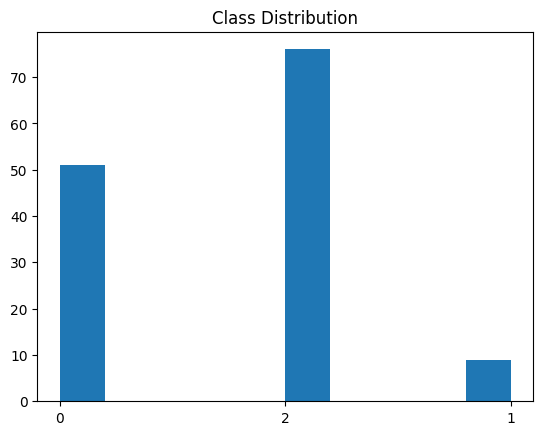

In [19]:
# Class distribution in the test set
plt.hist(test_df['label'].astype(str))
plt.title("Class Distribution")
plt.show()

## FINE-TUNED COVID-TWITTER-BERT

In [13]:
train_df = pd.DataFrame({"text": train_texts, "label": train_labels})
test_df = pd.DataFrame({"text": test_texts, "label": test_labels})

dataset_train = Dataset.from_pandas(train_df)
dataset_test = Dataset.from_pandas(test_df)

Load covid-twitter-bert model and Tokenize

In [14]:
model_name = "digitalepidemiologylab/covid-twitter-bert"

tokenizer = AutoTokenizer.from_pretrained(model_name)

def tokenize(batch):
    return tokenizer(
        batch["text"],
        truncation=True,
        max_length=64,
        padding="max_length" #necessary so all input vectors are of the same size
        )

dataset_train = dataset_train.map(tokenize, batched=True)
dataset_test = dataset_test.map(tokenize, batched=True)

Map:   0%|          | 0/540 [00:00<?, ? examples/s]

Map:   0%|          | 0/136 [00:00<?, ? examples/s]

In [15]:
model = AutoModelForSequenceClassification.from_pretrained(
    model_name,
    num_labels=3
)

Loading weights:   0%|          | 0/391 [00:00<?, ?it/s]

[transformers] BertForSequenceClassification LOAD REPORT from: digitalepidemiologylab/covid-twitter-bert
Key                                        | Status     | 
-------------------------------------------+------------+-
cls.predictions.transform.dense.weight     | UNEXPECTED | 
cls.seq_relationship.bias                  | UNEXPECTED | 
cls.seq_relationship.weight                | UNEXPECTED | 
cls.predictions.bias                       | UNEXPECTED | 
cls.predictions.decoder.weight             | UNEXPECTED | 
cls.predictions.transform.LayerNorm.weight | UNEXPECTED | 
cls.predictions.transform.LayerNorm.bias   | UNEXPECTED | 
cls.predictions.decoder.bias               | UNEXPECTED | 
cls.predictions.transform.dense.bias       | UNEXPECTED | 
classifier.bias                            | MISSING    | 
classifier.weight                          | MISSING    | 

Notes:
- UNEXPECTED:	can be ignored when loading from different task/architecture; not ok if you expect identical arch.
- MISSI

Define training arguiments for fine-tuning and training the model

In [16]:
training_args = TrainingArguments(
    learning_rate=2e-5,
    per_device_train_batch_size=8,
    per_device_eval_batch_size=8,
    num_train_epochs=3,
    weight_decay=0.01,
    seed=42,
    data_seed=42
)

train the model

In [17]:
trainer = Trainer(
    model=model,
    args=training_args,
    train_dataset=dataset_train,
    eval_dataset=dataset_test
)

trainer.train()

Step,Training Loss


Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

TrainOutput(global_step=204, training_loss=0.5195484161376953, metrics={'train_runtime': 97.0009, 'train_samples_per_second': 16.701, 'train_steps_per_second': 2.103, 'total_flos': 188716738705920.0, 'train_loss': 0.5195484161376953, 'epoch': 3.0})

Evaluations

In [18]:
preds = trainer.predict(dataset_test)
y_pred = np.argmax(preds.predictions, axis=1)
transformer_cls_report = classification_report(test_labels, y_pred)
print(transformer_cls_report)

              precision    recall  f1-score   support

           0       0.58      0.71      0.64        51
           1       0.00      0.00      0.00         9
           2       0.77      0.75      0.76        76

    accuracy                           0.68       136
   macro avg       0.45      0.49      0.47       136
weighted avg       0.65      0.68      0.66       136



/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))
/usr/local/lib/python3.12/dist-packages/sklearn/metrics/_classification.py:1565: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", len(result))


The fine-tuned COVID-Twitter-BERT model improved overall performance, increasing accuracy from 0.63 to 0.68 and macro F1 from 0.40 to 0.47. However, the model was still unable to correctly identify the supportive class, achieving an F1 score of 0.00 for that category. These results suggest that the limited number of supportive examples still hindered performance despite the use of a more complpex transformer model.

| Metric       | TF-IDF + LR | COVID-Twitter-BERT |
| ------------ | ----------: | -----------------: |
| Accuracy     |        0.63 |           **0.68** |
| Macro F1     |        0.40 |           **0.47** |
| Weighted F1  |        0.58 |           **0.66** |
